In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [32]:
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

pd.set_option('display.max_columns', None)

df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,YearsCode,YearsCodePro,DevType,OrgSize,PurchaseInfluence,BuyNewTool,BuildvsBuy,TechEndorse,Country,Currency,CompTotal,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,WebframeHaveWorkedWith,WebframeWantToWorkWith,WebframeAdmired,EmbeddedHaveWorkedWith,EmbeddedWantToWorkWith,EmbeddedAdmired,MiscTechHaveWorkedWith,MiscTechWantToWorkWith,MiscTechAdmired,ToolsTechHaveWorkedWith,ToolsTechWantToWorkWith,ToolsTechAdmired,NEWCollabToolsHaveWorkedWith,NEWCollabToolsWantToWorkWith,NEWCollabToolsAdmired,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackAsyncAdmired,OfficeStackSyncHaveWorkedWith,OfficeStackSyncWantToWorkWith,OfficeStackSyncAdmired,AISearchDevHaveWorkedWith,AISearchDevWantToWorkWith,AISearchDevAdmired,NEWSOSites,SOVisitFreq,SOAccount,SOPartFreq,SOHow,SOComm,AISelect,AISent,AIBen,AIAcc,AIComplex,AIToolCurrently Using,AIToolInterested in Using,AIToolNot interested in Using,AINextMuch more integrated,AINextNo change,AINextMore integrated,AINextLess integrated,AINextMuch less integrated,AIThreat,AIEthics,AIChallenges,TBranch,ICorPM,WorkExp,Knowledge_1,Knowledge_2,Knowledge_3,Knowledge_4,Knowledge_5,Knowledge_6,Knowledge_7,Knowledge_8,Knowledge_9,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States of America,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,I have never visited Stack Overflow or the Sta...,NaN,NaN,NaN,NaN,NaN,Yes,Very favorable,Increase productivity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,20,17,"Developer, full-stack",NaN,NaN,NaN,NaN,NaN,United Kingdom of Great Britain and Northern I...,NaN,NaN,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Dynamodb;MongoDB;PostgreSQL,PostgreSQL,PostgreSQL,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Express;Next.js;Node.js;React,Express;Htmx;Node.js;React;Remix,Express;Node.js;React,NaN,NaN,NaN,NaN,NaN,NaN,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,MacOS;Windows,MacOS,NaN,NaN,NaN,Microsoft Teams;Slack,Slack,Slack,NaN,NaN,NaN,Stack Overflow for Teams (private knowledge sh...,Multiple times per day,Yes,Multiple times per day,Quickly finding code solutions;Finding reliabl...,"Yes, definitely","No, and I don't plan to",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Individual contributor,17.0,Agree,Disagree,Agree,Agree,Agree,Neither agree nor disa

#### Step 1: Handling Missing Data

In [33]:
print("Missing values before handling:")
print(df[['Employment', 'JobSat', 'RemoteWork']].isna().sum())

# Employment: check first — this column has 0 missing values in the raw data,
# so no imputation is needed here.

# RemoteWork: ~16% missing — low enough that mode-imputation is defensible
# for a simple categorical field.
remote_work_mode = df['RemoteWork'].mode()[0]
df['RemoteWork'] = df['RemoteWork'].fillna(remote_work_mode)

# JobSat: ~55% missing — far too high to fill with a mean/mode. Doing so would
# manufacture a majority "fake" value and badly distort any group-level analysis
# later (e.g. median JobSat by experience level, in Step 4). Best practice here
# is to leave it as NaN and let aggregate functions skip missing values
# automatically — so no fillna() is applied to JobSat.

print("\nMissing values after handling:")
print(df[['Employment', 'JobSat', 'RemoteWork']].isna().sum())

Missing values before handling:
Employment        0
JobSat        36311
RemoteWork    10631
dtype: int64

Missing values after handling:
Employment        0
JobSat        36311
RemoteWork        0
dtype: int64


#### Step 2: Analysis of Experience and Job Satisfaction

In [34]:
# ===================== Step 4: Experience vs Job Satisfaction =====================

# Clean YearsCodePro: convert text categories to numeric equivalents
df['YearsCodePro'] = df['YearsCodePro'].replace('Less than 1 year', '0')
df['YearsCodePro'] = df['YearsCodePro'].replace('More than 50 years', '50')

# Convert to numeric, keeping genuine missing values as NaN
# (plain int can't hold NaN — that's what caused the earlier ValueError)
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

print(df['YearsCodePro'].describe())

# Create experience ranges (matches the lab's suggested 0-5 / 5-10 / 10-20 / >20)
bins = [0, 5, 10, 20, 100]
group_names = ['Junior (0-5)', 'Lower Mid-Level (5-10)', 'Upper Mid-Level (10-20)', 'Senior (20+)']

df['ExperienceLevel'] = pd.cut(df['YearsCodePro'], bins=bins, labels=group_names, include_lowest=True)

print(df['ExperienceLevel'].value_counts())

# Median JobSat per experience range — groupby handles all four groups at once
# and automatically skips the NaN JobSat rows within each group
median_jobsat_by_experience = df.groupby('ExperienceLevel')['JobSat'].median()
print(median_jobsat_by_experience)

count    51610.000000
mean        10.183375
std          9.105414
min          0.000000
25%          3.000000
50%          7.000000
75%         15.000000
max         50.000000
Name: YearsCodePro, dtype: float64
ExperienceLevel
Junior (0-5)               20497
Lower Mid-Level (5-10)     12653
Upper Mid-Level (10-20)    11625
Senior (20+)                6835
Name: count, dtype: int64
ExperienceLevel
Junior (0-5)               7.0
Lower Mid-Level (5-10)     7.0
Upper Mid-Level (10-20)    8.0
Senior (20+)               8.0
Name: JobSat, dtype: float64


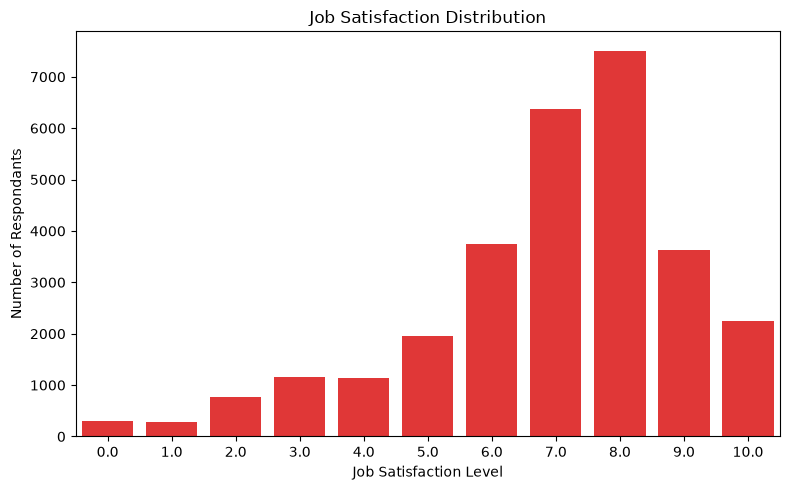

In [35]:
# Visualize with a bar plot
plt.figure(figsize=(8, 5))
sns.countplot(x='JobSat', data=df, color="#FC1B1BA6")
plt.title('Job Satisfaction Distribution')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Number of Respondants')
plt.tight_layout()
plt.show()

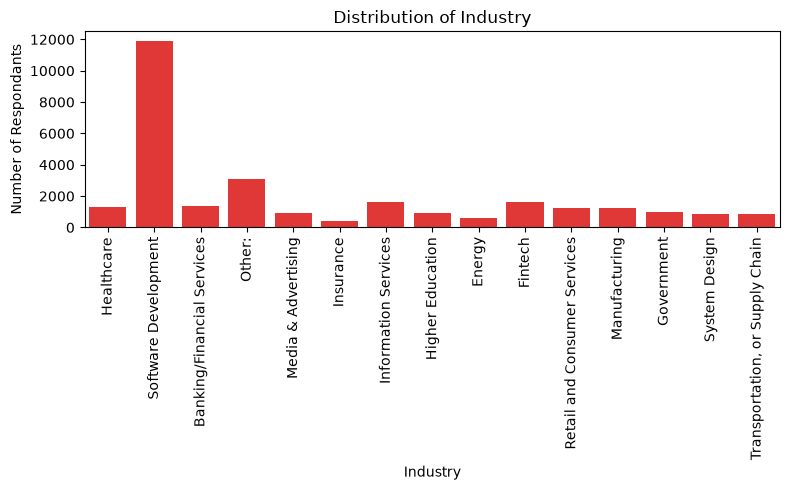

In [36]:
df['Industry'] = df['Industry'].replace('Internet, Telecomm or Information Services', 'Information Services')
df['Industry'] = df['Industry'].replace('Computer Systems Design and Services', 'System Design')
df['Industry'] = df['Industry'].replace('Media & Advertising Services', 'Media & Advertising')

df['Industry'].value_counts()
plt.figure(figsize=(8, 5))
sns.countplot(x='Industry', data=df, color="#FC1B1BA6")
plt.title('Distribution of Industry')
plt.xlabel('Industry')
plt.ylabel('Number of Respondants')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### Step 3: Analyzing Remote Work Preferences by Job Role

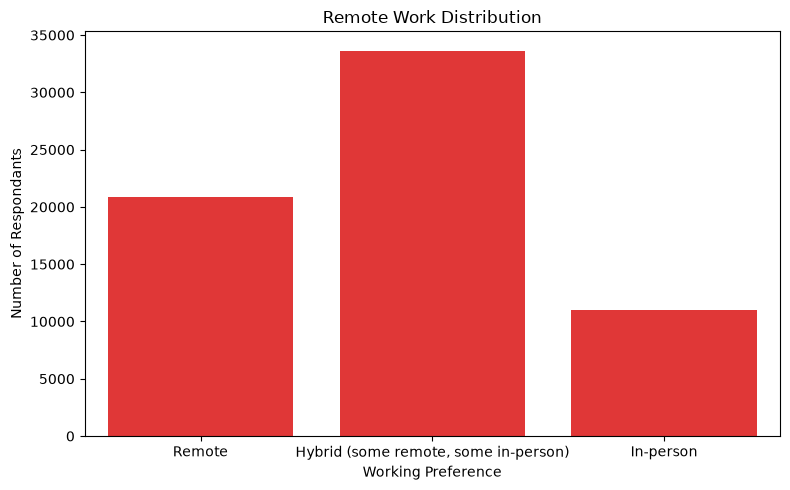

In [37]:
plt.figure(figsize=(8, 5))
sns.countplot(x='RemoteWork', data=df, color="#FC1B1BA6")
plt.title('Remote Work Distribution')
plt.xlabel('Working Preference')
plt.ylabel('Number of Respondants')
plt.tight_layout()
plt.show()

In [38]:
# --- Remote work by Employment type ---

df['RemoteWork'] = df['RemoteWork'].replace('Hybrid (some remote, some in-person)', 'Hybrid')

top_employment = df['Employment'].value_counts().head(6).index
filtered_emp = df[df['Employment'].isin(top_employment)]

remote_by_employment = pd.crosstab(filtered_emp['Employment'], filtered_emp['RemoteWork'], normalize='index') * 100

remote_by_employment

RemoteWork,Hybrid,In-person,Remote
Employment,,,
"Employed, full-time",44.302144,21.905177,33.792679
"Employed, full-time;Independent contractor, freelancer, or self-employed",37.391060,10.289570,52.319370
"Employed, part-time",45.497630,26.066351,28.436019
"Independent contractor, freelancer, or self-employed",26.888155,6.458935,66.652910
"Not employed, but looking for work",100.000000,0.000000,0.000000
"Student, full-time",100.000000,0.000000,0.000000


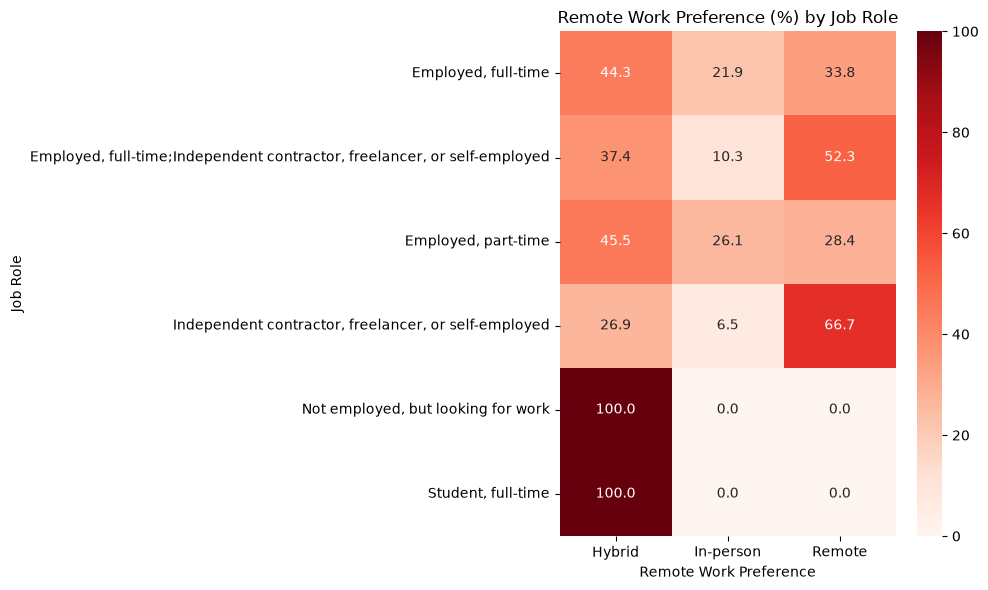

In [39]:
plt.figure(figsize=(10, 6))
sns.heatmap(remote_by_employment, annot=True, fmt='.1f', cmap='Reds')
plt.title('Remote Work Preference (%) by Job Role')
plt.xlabel('Remote Work Preference')
plt.ylabel('Job Role')
plt.tight_layout()
plt.show()

In [40]:
# Remote work by job role (DevType)
top_devtypes = df['DevType'].value_counts().head(10).index
filtered_dev = df[df['DevType'].isin(top_devtypes)]

remote_by_role = pd.crosstab(filtered_dev['DevType'], filtered_dev['RemoteWork'], normalize='index') * 100
remote_by_role

RemoteWork,Hybrid,In-person,Remote
DevType,,,
Academic researcher,65.670436,25.040388,9.289176
"Developer, back-end",44.631346,13.275584,42.093070
"Developer, desktop or enterprise applications",47.212194,23.626153,29.161653
"Developer, embedded applications or devices",51.632779,32.963648,15.403574
"Developer, front-end",44.968647,14.959689,40.071663
"Developer, full-stack",44.753560,17.212486,38.033954
"Developer, mobile",42.899555,17.219198,39.881247
Engineering manager,49.568627,12.549020,37.882353
Other (please specify):,55.492270,20.138324,24.369406


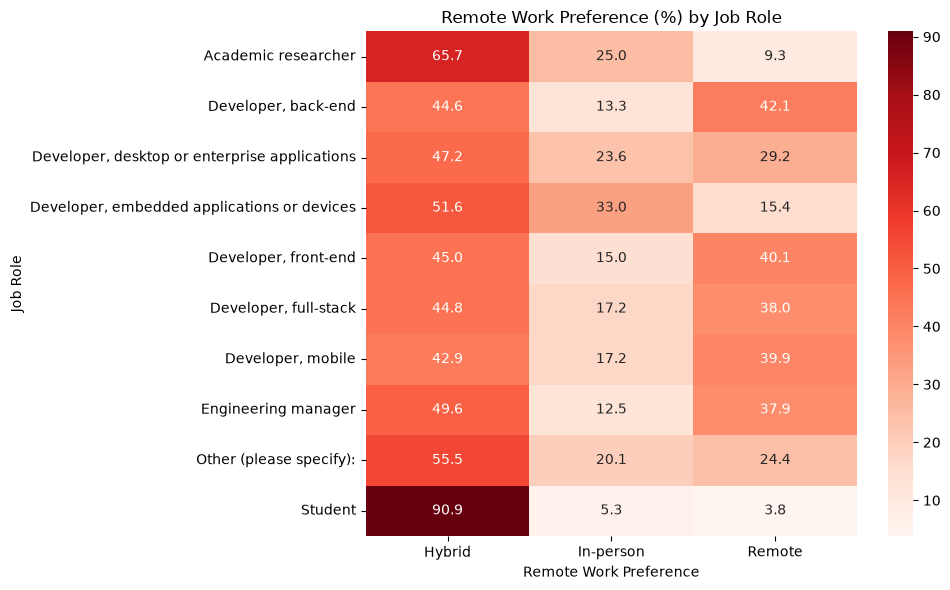

In [41]:
plt.figure(figsize=(10, 6))
sns.heatmap(remote_by_role, annot=True, fmt='.1f', cmap='Reds')
plt.title('Remote Work Preference (%) by Job Role')
plt.xlabel('Remote Work Preference')
plt.ylabel('Job Role')
plt.tight_layout()
plt.show()

#### Step 4: Analyzing Programming Language Trends by Region

In [42]:
df[['Country', 'LanguageHaveWorkedWith']].head(10)

,Country,LanguageHaveWorkedWith
0,United States of America,NaN
1,United Kingdom of Great Britain and Northern I...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...
2,United Kingdom of Great Britain and Northern I...,C#
3,Canada,C;C++;HTML/CSS;Java;JavaScript;PHP;PowerShell;...
4,Norway,C++;HTML/CSS;JavaScript;Lua;Python;Rust
5,United States of America,Bash/Shell (all shells);HTML/CSS;Java;JavaScri...
6,United States of America,R
7,Uzbekistan,HTML/CSS;JavaScript;TypeScript
8,United Kingdom of Great Britain and Northern I...,Lua
9,Serbia,HTML/CSS;JavaScript;TypeScript


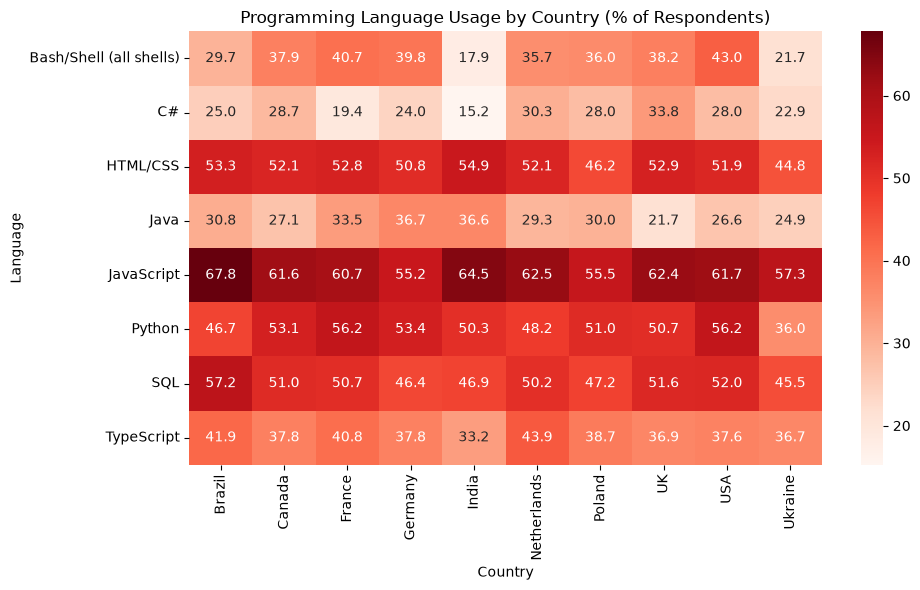

In [43]:
# Narrow to a handful of countries — otherwise this is unreadable across 183 of them

df['Country'] = df['Country'].replace('United Kingdom of Great Britain and Northern Ireland', 'UK')
df['Country'] = df['Country'].replace('United States of America', 'USA')

top_countries = df['Country'].value_counts().head(10).index
filtered = df[df['Country'].isin(top_countries)][['Country', 'LanguageHaveWorkedWith']].dropna()

# Split the multi-select column into individual languages, one row per language per respondent
filtered = filtered.assign(
    LanguageHaveWorkedWith=filtered['LanguageHaveWorkedWith'].str.split(';')
).explode('LanguageHaveWorkedWith')

# Count how many respondents in each country use each language
lang_counts = filtered.groupby(['Country', 'LanguageHaveWorkedWith']).size().reset_index(name='count')

# Keep only the most popular languages overall, to keep the chart readable
top_languages = filtered['LanguageHaveWorkedWith'].value_counts().head(8).index
lang_counts = lang_counts[lang_counts['LanguageHaveWorkedWith'].isin(top_languages)]

# Reshape into a language-by-country matrix
pivot = lang_counts.pivot(index='LanguageHaveWorkedWith', columns='Country', values='count').fillna(0)

# Convert counts to % of respondents per country — otherwise the US (a much bigger
# sample) would dominate the chart just because it has more people, not because
# any language is actually more popular there
respondents_per_country = df[df['Country'].isin(top_countries)].groupby('Country').size()
pivot_pct = pivot.div(respondents_per_country, axis=1) * 100

# Visualize as a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_pct, annot=True, fmt='.1f', cmap='Reds')
plt.title('Programming Language Usage by Country (% of Respondents)')
plt.xlabel('Country')
plt.ylabel('Language')
plt.tight_layout()
plt.show()

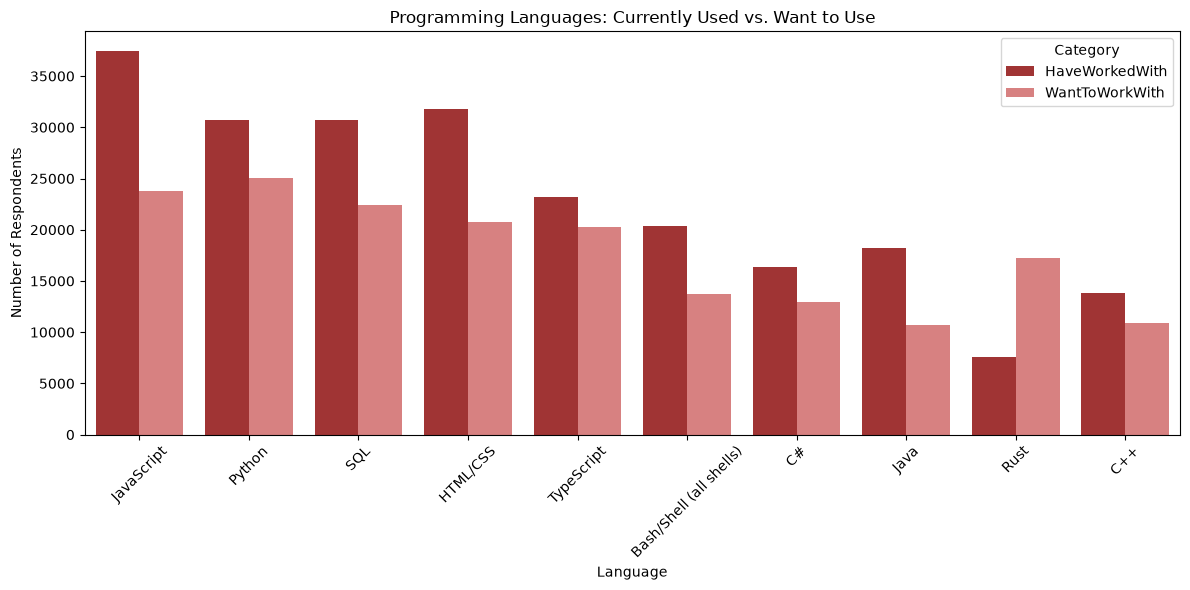

In [44]:
# Explode both multi-select columns into individual language mentions
have = df['LanguageHaveWorkedWith'].dropna().str.split(';').explode()
want = df['LanguageWantToWorkWith'].dropna().str.split(';').explode()

have_counts = have.value_counts()
want_counts = want.value_counts()

# Combine into one comparison table, aligned by language
lang_compare = pd.DataFrame({'HaveWorkedWith': have_counts, 'WantToWorkWith': want_counts}).fillna(0)

# Focus on the most-mentioned languages overall
top_languages = (lang_compare['HaveWorkedWith'] + lang_compare['WantToWorkWith']).sort_values(ascending=False).head(10).index
lang_compare_top = lang_compare.loc[top_languages].reset_index().rename(columns={'index': 'Language'})

# Reshape long-form for a grouped bar chart
lang_compare_long = lang_compare_top.melt(id_vars='Language', var_name='Category', value_name='Count')

plt.figure(figsize=(12, 6))
sns.barplot(x='Language', y='Count', hue='Category', data=lang_compare_long, palette=['#B22222', '#E57373'])
plt.title('Programming Languages: Currently Used vs. Want to Use')
plt.xlabel('Language')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



#### Step 5: Correlation Between Experience and Satisfaction

Correlation between YearsCodePro and JobSatPoints_1: -0.028


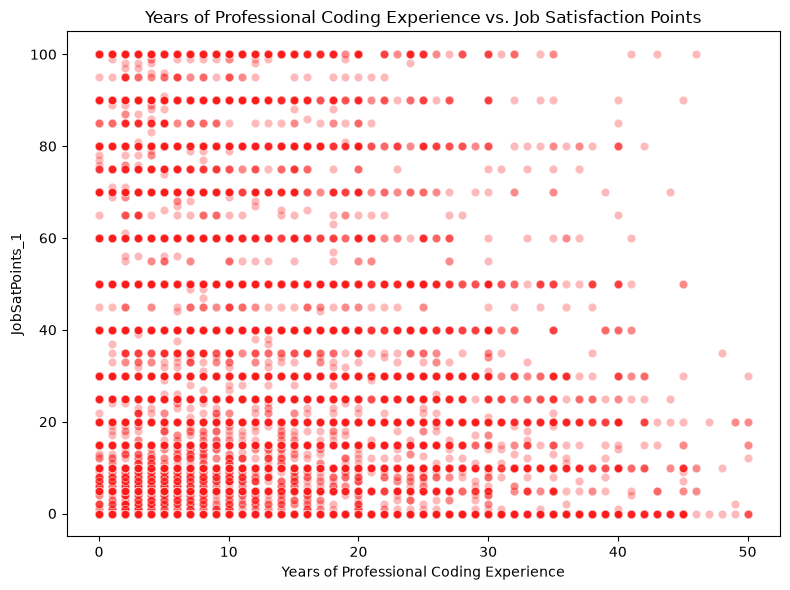

In [72]:
scatter_data = df[['YearsCodePro', 'JobSatPoints_1']].dropna()

correlation = scatter_data['YearsCodePro'].corr(scatter_data['JobSatPoints_1'])
print(f"Correlation between YearsCodePro and JobSatPoints_1: {correlation:.3f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(x='YearsCodePro', y='JobSatPoints_1', data=scatter_data, alpha=0.3, color="#FC1B1BA6")
plt.title('Years of Professional Coding Experience vs. Job Satisfaction Points')
plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('JobSatPoints_1')
plt.tight_layout()
plt.show()

<Axes: xlabel='YearsCodePro', ylabel='JobSatPoints_1'>

<Figure size 1000x600 with 0 Axes>

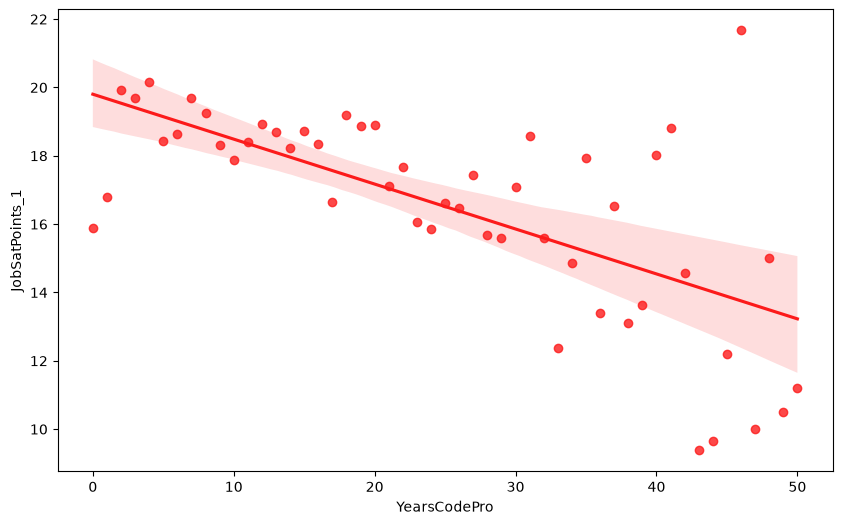

In [47]:
plt.figure(figsize=(10, 6))

df_ExpSat = df[['YearsCodePro', 'JobSatPoints_1']]

ExperienceSat = df_ExpSat.groupby(['YearsCodePro'],as_index=False).mean()

plt.figure(figsize=(10, 6))
sns.regplot(x='YearsCodePro', y='JobSatPoints_1', data=ExperienceSat, color="#FC1B1BA6")


<Axes: xlabel='YearsCodePro', ylabel='JobSat'>

<Figure size 1000x600 with 0 Axes>

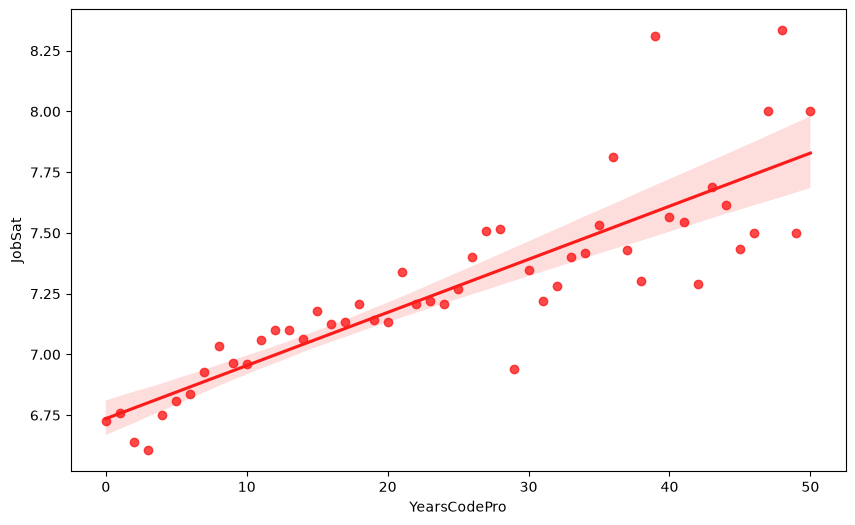

In [48]:
plt.figure(figsize=(10, 6))

df_ExpSat = df[['YearsCodePro', 'JobSat']]

ExperienceSat = df_ExpSat.groupby(['YearsCodePro'],as_index=False).mean()

plt.figure(figsize=(10, 6))
sns.regplot(x='YearsCodePro', y='JobSat', data=ExperienceSat, color="#FC1B1BA6")


In [49]:
correlation_data = df[['YearsCodePro', 'JobSat']].dropna()

pearson_corr = correlation_data['YearsCodePro'].corr(correlation_data['JobSat'], method='pearson')
spearman_corr = correlation_data['YearsCodePro'].corr(correlation_data['JobSat'], method='spearman')

print(f"Pearson correlation:  {pearson_corr:.3f}")
print(f"Spearman correlation: {spearman_corr:.3f}")

Pearson correlation:  0.104
Spearman correlation: 0.119


<h3>Step 6: Further Correlation Analysis

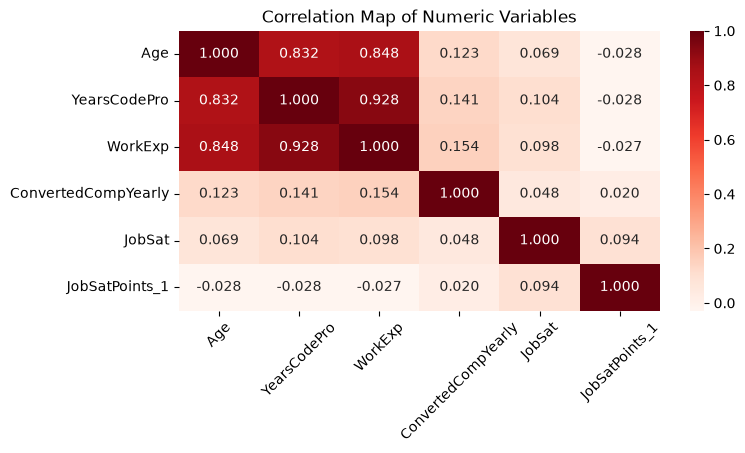

In [80]:
df['Age'] = df['Age'].replace('25-34 years old', '30')
df['Age'] = df['Age'].replace('35-44 years old', '40')
df['Age'] = df['Age'].replace('18-24 years old', '21')
df['Age'] = df['Age'].replace('45-54 years old', '50')
df['Age'] = df['Age'].replace('55-64 years old', '60')
df['Age'] = df['Age'].replace('Under 18 years old', '18')
df['Age'] = df['Age'].replace('65 years or older', '65')
dfAge = df.drop(df[df['Age'] == 'Prefer not to say'].index)
dfAge['Age'] = dfAge['Age'].astype('int')

numeric_correlation_df = dfAge[['Age', 'YearsCodePro', 'WorkExp', 'ConvertedCompYearly', 'JobSat','JobSatPoints_1']].corr()

# Visualize as a heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(numeric_correlation_df, annot=True, fmt='.3f', cmap='Reds')
plt.title('Correlation Map of Numeric Variables')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


#### Step 7: Educational Background and Employment Type

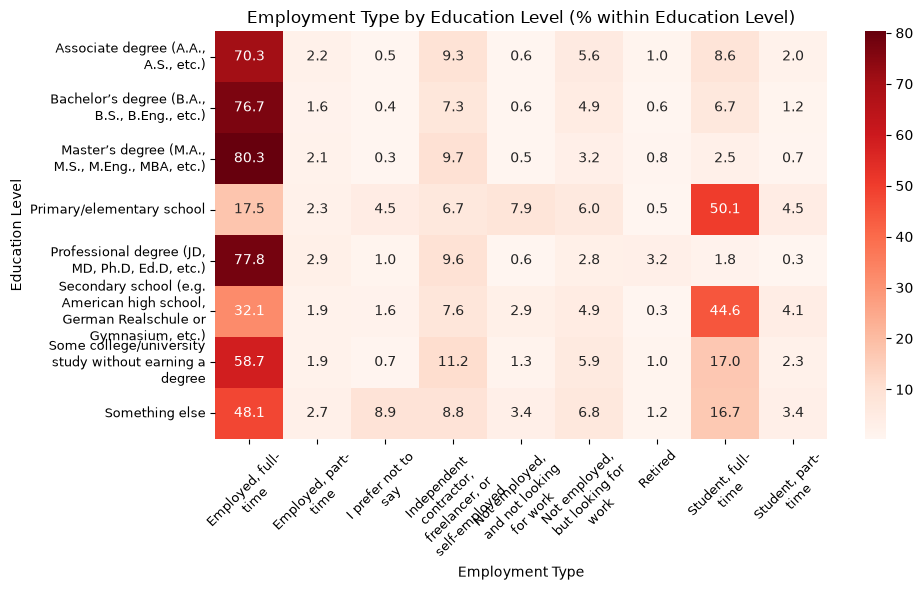

In [79]:
import textwrap

# Collapse multi-select Employment answers down to primary employment status
df['EmploymentClean'] = df['Employment'].str.split(';').str[0]

# Build the crosstab: % distribution of employment type within each education level
edu_employment_crosstab = pd.crosstab(df['EdLevel'], df['EmploymentClean'], normalize='index') * 100

# Wrap long axis labels so they display cleanly
def wrap_labels(labels, width=30):
    return [textwrap.fill(str(label), width) for label in labels]

edu_employment_crosstab.index = wrap_labels(edu_employment_crosstab.index, width=25)
edu_employment_crosstab.columns = wrap_labels(edu_employment_crosstab.columns, width=15)

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(edu_employment_crosstab.round(1), annot=True, fmt='.1f', cmap='Reds')
plt.title('Employment Type by Education Level (% within Education Level)')
plt.xlabel('Employment Type')
plt.ylabel('Education Level')
plt.xticks(rotation=45, fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

#### Step 8: Detecting Outliers

In [54]:
# Detecting outliers in compensation using IQR method
from scipy.stats import iqr
IQRComp = iqr(df['ConvertedCompYearly'].dropna())

Q1 = np.percentile(df['ConvertedCompYearly'].dropna(), 25) - (1.5 * IQRComp)
Q3 = np.percentile(df['ConvertedCompYearly'].dropna(), 75) + (1.5 * IQRComp)

# Q1 is negative, it is impossible to have a negative salary therefore no small outliers

HighOutliers = df[df['ConvertedCompYearly'] > Q3]

HighOutliers['ConvertedCompYearly']

428      230000.0
456      300000.0
461      254425.0
529      650000.0
545      400000.0
           ...   
40952    750000.0
41000    235000.0
41001    260000.0
41027    700000.0
41187    222834.0
Name: ConvertedCompYearly, Length: 978, dtype: float64

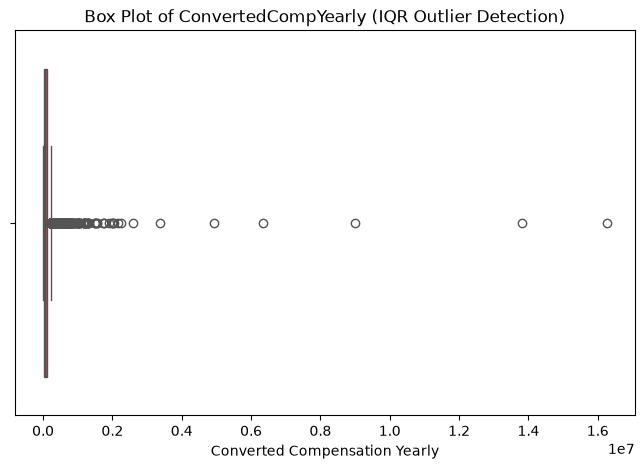

In [55]:
# Plotting outliers with a boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='ConvertedCompYearly', data=df, color="#FC1B1BA6")
plt.title('Box Plot of ConvertedCompYearly (IQR Outlier Detection)')
plt.xlabel('Converted Compensation Yearly')
plt.show()

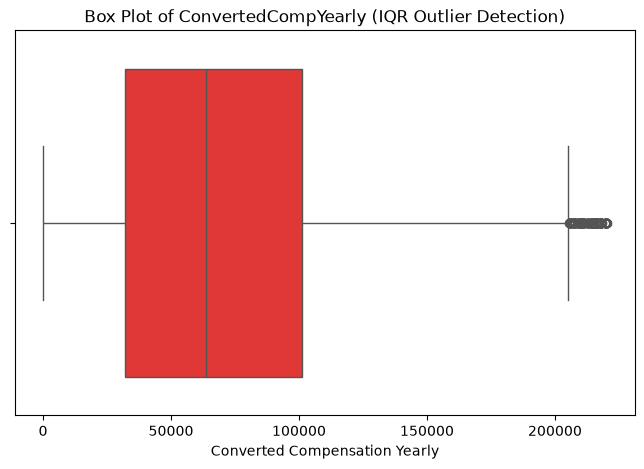

65000.0


In [ ]:
# Removing outliers and replotting box plot

df_No_Outlier = df.drop(df[df['ConvertedCompYearly'] > Q3].index)

plt.figure(figsize=(8, 5))
sns.boxplot(x='ConvertedCompYearly', data=df_No_Outlier, color="#FC1B1BA6")
plt.title('Box Plot of ConvertedCompYearly (IQR Outlier Detection)')
plt.xlabel('Converted Compensation Yearly')
plt.show()


             count           mean    median           std    min       max
Country                                                                   
USA           3990  130208.145113  130000.0  47472.030690    1.0  220207.0
Canada         838   90088.501193   83597.0  41771.967779   58.0  218079.0
UK            1326   89405.377828   82802.0  41412.337914   38.0  216559.0
Germany       2021   73261.870361   71962.0  34047.491895    1.0  214812.0
Netherlands    552   78445.461957   69814.0  39899.374430  322.0  214812.0
Poland         582   59201.692440   55061.0  36664.530310   24.0  214812.0
France         909   60076.213421   53703.0  30111.773751    1.0  214812.0
Ukraine       1466   33847.266712   26033.0  33281.741193    1.0  190000.0
Brazil         678   34416.554572   23311.0  33880.723962   19.0  205136.0
India         1030   24283.957282   16749.0  23829.677182    1.0  220128.0


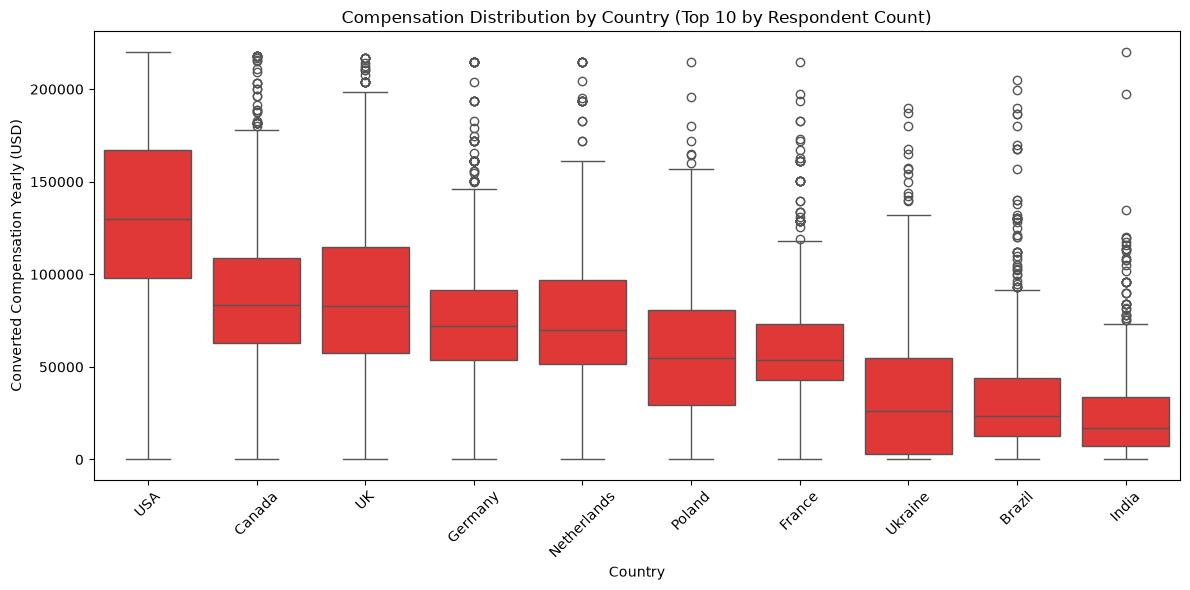

In [81]:
# Focus on the countries with the most respondents — plotting all countries
# would be unreadable, and countries with very few responses give
# unreliable/misleading distributions

top_countries = df_No_Outlier['Country'].value_counts().head(10).index
df_top_countries = df_No_Outlier[df_No_Outlier['Country'].isin(top_countries)]

# Summary statistics per country
country_stats = df_top_countries.groupby('Country')['ConvertedCompYearly'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).sort_values('median', ascending=False)

print(country_stats)

# Order countries by median compensation, highest to lowest, for a cleaner plot
country_order = country_stats.index

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_top_countries,
    x='Country',
    y='ConvertedCompYearly',
    order=country_order,
    color="#FC1B1BA6"
)
plt.title(f'Compensation Distribution by Country (Top {top_n} by Respondent Count)')
plt.xlabel('Country')
plt.ylabel('Converted Compensation Yearly (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()